##### ### The University of Melbourne, School of Computing and Information Systems
# COMP30027 Machine Learning, 2026 Semester 1

## Assignment 1: Income Classification with Naïve Bayes


**Student ID(s):**     1615136

**Student Name:**      Skanda Ramanan


This iPython notebook is a template which you will use for your Assignment 1 submission.

**NOTE: YOU SHOULD ADD YOUR RESULTS, GRAPHS, AND FIGURES FROM YOUR OBSERVATIONS IN THIS FILE TO YOUR REPORT (the PDF file).** Results, figures, etc. which appear in this file but are NOT included in your report will not be marked.

**Adding proper comments to your code is MANDATORY. **

## 1. Supervised model training


In [53]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

TRAIN_PATH = 'adult_supervised_train.csv'
TARGET_COLUMN = 'income'
CLASS_LABELS = {0: '<=50K', 1: '>50K'}
CONTINUOUS_FEATURES = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
CATEGORICAL_FEATURES = ['workclass', 'education', 'marital-status', 'occupation',
                        'relationship', 'race', 'sex', 'native-country']

# --- Data Loading ---
train_df = pd.read_csv(TRAIN_PATH)
print(f"Raw training set shape: {train_df.shape}")
print(f"\nColumn dtypes:\n{train_df.dtypes}")
print("\nFirst 3 rows:")
train_df.head(3)

Raw training set shape: (16280, 15)

Column dtypes:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

First 3 rows:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,63,Private,219337,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,3471,0,45,United-States,<=50K
1,44,State-gov,33658,Masters,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,7688,0,50,United-States,>50K
2,18,Private,157193,12th,8,Never-married,Other-service,Own-child,White,Male,0,0,30,Italy,<=50K


In [54]:
# --- Preprocessing ---


def preprocess_adult_frame(df):
    """Clean a labelled Adult split: missing values dropped, fnlwgt removed, income encoded."""
    cleaned_df = df.copy()

    # The updated CSVs store missing values as blank fields, which pandas usually reads as NaN.
    # This extra replace catches any whitespace-only strings before we drop incomplete rows.
    cleaned_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

    rows_before = len(cleaned_df)
    cleaned_df.dropna(inplace=True)
    rows_after = len(cleaned_df)

    cleaned_df = cleaned_df.drop(columns=['fnlwgt']).copy()
    cleaned_df[TARGET_COLUMN] = cleaned_df[TARGET_COLUMN].map({'<=50K': 0, '>50K': 1})

    return cleaned_df, rows_before - rows_after


train_df, dropped_rows = preprocess_adult_frame(train_df)
X_train_cont = train_df[CONTINUOUS_FEATURES].astype(float)
X_train_cat = train_df[CATEGORICAL_FEATURES].copy()
y_train = train_df[TARGET_COLUMN]

class_distribution = y_train.value_counts().sort_index().rename(index=CLASS_LABELS)

rows_total = len(train_df) + dropped_rows
print(f"Dropped {dropped_rows} rows with missing values ({rows_total} -> {len(train_df)})")
print(f"\nContinuous features: {CONTINUOUS_FEATURES}")
print(f"Categorical features: {CATEGORICAL_FEATURES}")
print(f"\nClass distribution:\n{class_distribution}")

Dropped 1204 rows with missing values (16280 -> 15076)

Continuous features: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Class distribution:
income
<=50K    11369
>50K      3707
Name: count, dtype: int64


In [55]:
# --- Train Mixed Naive Bayes ---


def fit_mixed_nb(X_cont, X_cat, y, alpha=1.0):
    """Fit Gaussian NB on continuous features and Categorical NB on categorical ones."""
    gnb = GaussianNB()
    gnb.fit(X_cont, y)

    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_cat_enc = encoder.fit_transform(X_cat).astype(int)

    cnb = CategoricalNB(alpha=alpha)
    cnb.fit(X_cat_enc, y)

    return {
        'gnb': gnb,
        'cnb': cnb,
        'encoder': encoder,
        'classes': gnb.classes_,
        'alpha': alpha,
    }


def transform_categorical_features(X_cat, encoder):
    """Apply the training encoder so category handling stays consistent everywhere."""
    return encoder.transform(X_cat).astype(int)


def gaussian_log_likelihood(X_cont, gnb):
    """Compute Gaussian feature log-likelihoods using the learned public parameters."""
    X_cont = np.asarray(X_cont, dtype=float)
    variances = np.maximum(gnb.var_, 1e-9)
    means = gnb.theta_

    squared_error = (X_cont[:, None, :] - means[None, :, :]) ** 2
    log_density = -0.5 * (
        np.log(2 * np.pi * variances)[None, :, :] + squared_error / variances[None, :, :]
    )
    return log_density.sum(axis=2)


def categorical_log_likelihood(X_cat_enc, cnb):
    """Sum the learned categorical log-probabilities feature by feature."""
    X_cat_enc = np.asarray(X_cat_enc, dtype=int)
    n_samples = X_cat_enc.shape[0]
    n_classes = len(cnb.class_count_)
    log_likelihood = np.zeros((n_samples, n_classes))

    for feature_idx, feature_log_prob in enumerate(cnb.feature_log_prob_):
        encoded_values = X_cat_enc[:, feature_idx]
        known_mask = encoded_values >= 0

        # Unknown categories are ignored here; they contribute equally to both classes.
        if np.any(known_mask):
            log_likelihood[known_mask] += feature_log_prob[:, encoded_values[known_mask]].T

    return log_likelihood


def predict_mixed_nb(X_cont, X_cat, model):
    """Combine the continuous and categorical pieces into one posterior score."""
    X_cat_enc = transform_categorical_features(X_cat, model['encoder'])
    log_prior = np.log(model['gnb'].class_prior_)
    log_posterior = (
        log_prior
        + gaussian_log_likelihood(X_cont, model['gnb'])
        + categorical_log_likelihood(X_cat_enc, model['cnb'])
    )
    predictions = model['classes'][np.argmax(log_posterior, axis=1)]
    return predictions, log_posterior


mixed_nb_model = fit_mixed_nb(X_train_cont, X_train_cat, y_train, alpha=1.0)
gnb = mixed_nb_model['gnb']
cnb = mixed_nb_model['cnb']
encoder = mixed_nb_model['encoder']

print('Mixed Naive Bayes model trained successfully.')
print(f"  Classes: {gnb.classes_}")
print(f"  Laplace smoothing alpha: {mixed_nb_model['alpha']}")

# Training accuracy is just a quick smoke test that the pipeline is wired up properly.
y_pred_train, train_log_posterior = predict_mixed_nb(X_train_cont, X_train_cat, mixed_nb_model)
train_acc = accuracy_score(y_train, y_pred_train)
print(f"\nTraining accuracy (sanity check): {train_acc:.4f}")

Mixed Naive Bayes model trained successfully.
  Classes: [0 1]
  Laplace smoothing alpha: 1.0

Training accuracy (sanity check): 0.8289


In [56]:
# --- Q1.1: Prior Probabilities ---

prior_low = gnb.class_prior_[0]   # P(<=50K)
prior_high = gnb.class_prior_[1]  # P(>50K)

print("Prior Probabilities P(c):")
print(f"  P(<=50K) = {prior_low:.4f}")
print(f"  P(>50K)  = {prior_high:.4f}")
print(f"\nClass ratio (<=50K : >50K) = {prior_low/prior_high:.2f} : 1")
print(f"\nThe training set exhibits class imbalance — the <=50K class is "
      f"~{prior_low/prior_high:.1f}x more frequent than >50K.")

Prior Probabilities P(c):
  P(<=50K) = 0.7541
  P(>50K)  = 0.2459

Class ratio (<=50K : >50K) = 3.07 : 1

The training set exhibits class imbalance — the <=50K class is ~3.1x more frequent than >50K.


In [57]:
# --- Q1.2: Continuous Feature Statistics per Class ---

# Extract learned parameters from GaussianNB
means = gnb.theta_       # shape (n_classes, n_features)
variances = gnb.var_     # shape (n_classes, n_features)
stds = np.sqrt(variances)

# Build a summary table
cont_stats = pd.DataFrame({
    'Feature': CONTINUOUS_FEATURES,
    'Mean (<=50K)': means[0],
    'Std (<=50K)': stds[0],
    'Mean (>50K)': means[1],
    'Std (>50K)': stds[1],
})

# Measure class separation via Cohen's d: |μ1 - μ2| / sqrt((σ1² + σ2²) / 2)
cont_stats["Cohen's d"] = np.abs(means[1] - means[0]) / np.sqrt((variances[0] + variances[1]) / 2)
cont_stats = cont_stats.sort_values("Cohen's d", ascending=False)

print("Continuous Feature Statistics by Class:")
print("=" * 90)
print(cont_stats.to_string(index=False, float_format='{:.4f}'.format))
print("\n(Sorted by Cohen's d — larger values indicate greater separation between classes)")

Continuous Feature Statistics by Class:
       Feature  Mean (<=50K)  Std (<=50K)  Mean (>50K)  Std (>50K)  Cohen's d
 education-num        9.6293       2.4478      11.5946      2.3650     0.8166
           age       37.0508      13.7119      43.9385     10.3027     0.5679
hours-per-week       39.4286      11.9108      45.6423     10.3961     0.5558
  capital-gain      157.6660    1017.8632    3607.1467  13616.6230     0.3573
  capital-loss       55.9746     316.0201     202.3620    603.9910     0.3037

(Sorted by Cohen's d — larger values indicate greater separation between classes)


In [58]:
# --- Q1.3: Categorical Feature Probability Ratios ---

# Recover P(xj = v | c) for each categorical feature from the CategoricalNB model.
# cnb.feature_log_prob_ is a list of arrays, one per feature,
# each of shape (n_classes, n_categories_for_that_feature).

ratio_records = []

for feat_idx, feat_name in enumerate(CATEGORICAL_FEATURES):
    # Log-probabilities for this feature: shape (n_classes, n_categories)
    log_probs = cnb.feature_log_prob_[feat_idx]
    probs = np.exp(log_probs)  # convert to probabilities

    # Category labels from the encoder
    categories = encoder.categories_[feat_idx]

    for cat_idx, cat_value in enumerate(categories):
        p_given_low = probs[0, cat_idx]   # P(v | <=50K)
        p_given_high = probs[1, cat_idx]  # P(v | >50K)

        # R for >50K: how much more likely under >50K than <=50K
        r_high = p_given_high / p_given_low
        # R for <=50K: how much more likely under <=50K than >50K
        r_low = p_given_low / p_given_high

        ratio_records.append({
            'Feature': feat_name,
            'Value': cat_value,
            'P(v|<=50K)': p_given_low,
            'P(v|>50K)': p_given_high,
            'R (>50K)': r_high,
            'R (<=50K)': r_low,
        })

ratio_df = pd.DataFrame(ratio_records)

# Best category value per feature for each class
best_per_feature_high = ratio_df.loc[
    ratio_df.groupby('Feature')['R (>50K)'].idxmax(),
    ['Feature', 'Value', 'P(v|<=50K)', 'P(v|>50K)', 'R (>50K)']
].sort_values('R (>50K)', ascending=False)

best_per_feature_low = ratio_df.loc[
    ratio_df.groupby('Feature')['R (<=50K)'].idxmax(),
    ['Feature', 'Value', 'P(v|<=50K)', 'P(v|>50K)', 'R (<=50K)']
].sort_values('R (<=50K)', ascending=False)

print('Most Predictive Category Value per Feature for >50K:')
print('=' * 75)
print(best_per_feature_high.to_string(index=False, float_format='{:.4f}'.format))

print()
print('Most Predictive Category Value per Feature for <=50K:')
print('=' * 75)
print(best_per_feature_low.to_string(index=False, float_format='{:.4f}'.format))

print()

# Top 5 most predictive of >50K (highest R for >50K)
top5_high = ratio_df.nlargest(5, 'R (>50K)')[['Feature', 'Value', 'P(v|<=50K)', 'P(v|>50K)', 'R (>50K)']]
print('Top 5 Category Values Most Predictive of >50K:')
print('=' * 75)
print(top5_high.to_string(index=False, float_format='{:.4f}'.format))

print()

# Top 5 most predictive of <=50K (highest R for <=50K)
top5_low = ratio_df.nlargest(5, 'R (<=50K)')[['Feature', 'Value', 'P(v|<=50K)', 'P(v|>50K)', 'R (<=50K)']]
print('Top 5 Category Values Most Predictive of <=50K:')
print('=' * 75)
print(top5_low.to_string(index=False, float_format='{:.4f}'.format))

Most Predictive Category Value per Feature for >50K:
       Feature              Value  P(v|<=50K)  P(v|>50K)  R (>50K)
     education        Prof-school      0.0069     0.0545    7.9587
marital-status  Married-AF-spouse      0.0004     0.0019    4.2882
native-country             Taiwan      0.0008     0.0027    3.3832
     workclass       Self-emp-inc      0.0243     0.0792    3.2510
    occupation    Exec-managerial      0.0915     0.2534    2.7685
  relationship               Wife      0.0330     0.0905    2.7450
           sex               Male      0.6145     0.8469    1.3782
          race Asian-Pac-Islander      0.0259     0.0294    1.1322

Most Predictive Category Value per Feature for <=50K:
       Feature              Value  P(v|<=50K)  P(v|>50K)  R (<=50K)
  relationship          Own-child      0.1858     0.0097    19.1680
    occupation    Priv-house-serv      0.0064     0.0005    11.9315
     education                9th      0.0196     0.0030     6.6294
marital-status   

## 2. Supervised model evaluation

Raw test set shape: (16281, 15)
Dropped 1194 test rows with missing values (16281 -> 15087)

Overall test accuracy: 0.8307

Per-class breakdown:
              precision    recall  f1-score   support

       <=50K       0.85      0.93      0.89     11303
        >50K       0.72      0.53      0.61      3784

    accuracy                           0.83     15087
   macro avg       0.79      0.73      0.75     15087
weighted avg       0.82      0.83      0.82     15087



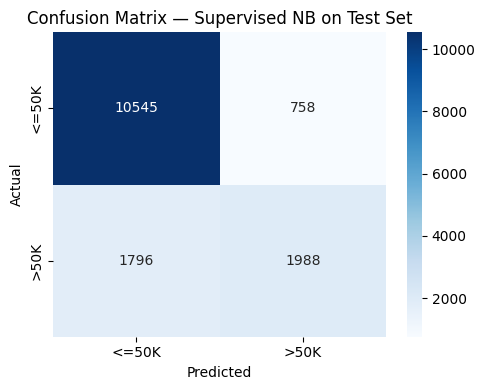

In [59]:
# --- Q2.1: Test Set Evaluation ---

TEST_PATH = 'adult_test.csv'

test_df_raw = pd.read_csv(TEST_PATH)
print(f"Raw test set shape: {test_df_raw.shape}")

test_df, dropped_test = preprocess_adult_frame(test_df_raw)
X_test_cont = test_df[CONTINUOUS_FEATURES].astype(float)
X_test_cat = test_df[CATEGORICAL_FEATURES].copy()
y_test = test_df[TARGET_COLUMN]

rows_total_test = len(test_df) + dropped_test
print(f"Dropped {dropped_test} test rows with missing values ({rows_total_test} -> {len(test_df)})")

# Predict on the held-out test set using the supervised model from Q1
y_pred_test, test_log_posterior = predict_mixed_nb(X_test_cont, X_test_cat, mixed_nb_model)

test_acc = accuracy_score(y_test, y_pred_test)
print(f"\nOverall test accuracy: {test_acc:.4f}")
print(f"\nPer-class breakdown:")
print(classification_report(y_test, y_pred_test, target_names=['<=50K', '>50K']))

# Confusion matrix visualisation
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Supervised NB on Test Set')
plt.tight_layout()
plt.show()

In [60]:
# --- Q2.2: Unseen Categories in Test Set ---

X_test_cat_enc = transform_categorical_features(X_test_cat, encoder)

# OrdinalEncoder maps categories absent from training to -1;
# categorical_log_likelihood treats them as neutral (contributes 0 to both classes).
unseen_per_instance = (X_test_cat_enc == -1).any(axis=1)
n_unseen = unseen_per_instance.sum()

print(f"Test instances with at least one unseen category value: "
      f"{n_unseen} / {len(test_df)} ({n_unseen / len(test_df) * 100:.1f}%)\n")

# Per-feature breakdown of which values are novel
for feat_idx, feat_name in enumerate(CATEGORICAL_FEATURES):
    col_unseen_count = (X_test_cat_enc[:, feat_idx] == -1).sum()
    if col_unseen_count > 0:
        train_vals = set(encoder.categories_[feat_idx])
        test_vals = set(X_test_cat[feat_name].unique())
        novel = sorted(test_vals - train_vals)
        print(f"  {feat_name}: {col_unseen_count} instance(s), unseen values = {novel}")

# Compare accuracy on the affected vs unaffected subsets
if n_unseen > 0:
    mask = unseen_per_instance
    n_seen = (~mask).sum()
    acc_unseen = accuracy_score(y_test.values[mask], y_pred_test[mask])
    acc_seen = accuracy_score(y_test.values[~mask], y_pred_test[~mask])
    print(f"\nAccuracy on instances WITH unseen values:    {acc_unseen:.4f} (n={n_unseen})")
    print(f"Accuracy on instances WITHOUT unseen values:  {acc_seen:.4f} (n={n_seen})")

print(f"\nHandling: unseen category values are encoded as -1 and skipped in the categorical "
      f"log-likelihood.\nThey contribute 0 to both class posteriors, so the prediction relies on "
      f"the remaining known features.\nNo test instances are discarded — every row still receives "
      f"a prediction.")

Test instances with at least one unseen category value: 1 / 15087 (0.0%)

  native-country: 1 instance(s), unseen values = ['Holand-Netherlands']

Accuracy on instances WITH unseen values:    0.0000 (n=1)
Accuracy on instances WITHOUT unseen values:  0.8308 (n=15086)

Handling: unseen category values are encoded as -1 and skipped in the categorical log-likelihood.
They contribute 0 to both class posteriors, so the prediction relies on the remaining known features.
No test instances are discarded — every row still receives a prediction.


(a) High-Confidence >50K Predictions (R >> 1)
 age   education     marital-status      occupation  hours-per-week  capital-gain actual predicted  correct         R
  47   Bachelors Married-civ-spouse Exec-managerial              55         99999   >50K      >50K     True 1.40e+217
  63     Masters Married-civ-spouse Farming-fishing              50         41310  <=50K      >50K    False 1.40e+217
  51 Prof-school           Divorced  Prof-specialty              60         27828   >50K      >50K     True 1.21e+160

(b) High-Confidence <=50K Predictions (R << 1)
 age education     marital-status        occupation  hours-per-week  capital-gain actual predicted  correct        R
  18      10th      Never-married     Other-service               3             0  <=50K     <=50K     True 9.24e-10
  35      11th          Separated   Priv-house-serv               8             0  <=50K     <=50K     True 8.88e-09
  23   7th-8th Married-civ-spouse Handlers-cleaners              30             0  

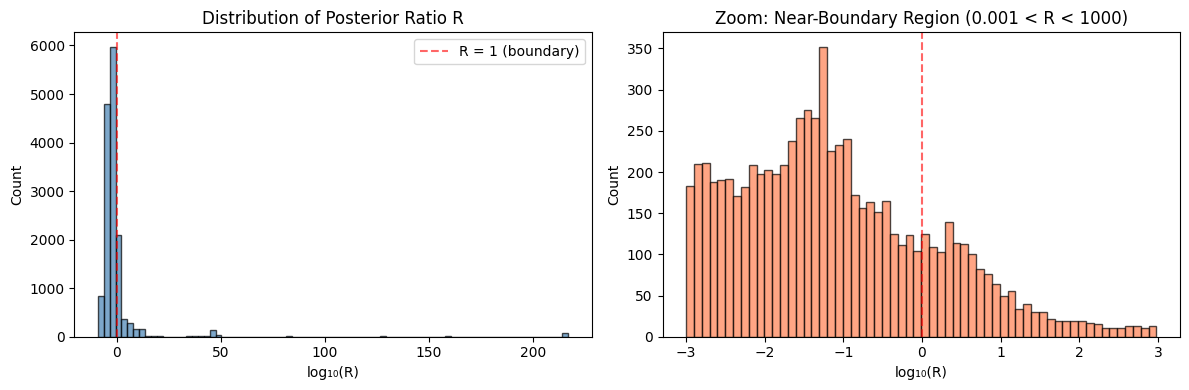

In [61]:
# --- Q2.3: Prediction Confidence (Posterior Ratio R) ---

# Following the spec: R = P(c1|x) / P(c2|x) where c1 = >50K, c2 = <=50K.
# R >> 1 → confident >50K;  R << 1 → confident <=50K;  R ≈ 1 → uncertain.
# In log space the normalisation constant cancels, so unnormalised log-posteriors suffice.
log_ratio = test_log_posterior[:, 1] - test_log_posterior[:, 0]
R_values = np.exp(np.clip(log_ratio, -500, 500))

test_results = test_df.reset_index(drop=True).copy()
test_results['predicted'] = y_pred_test
test_results['R'] = R_values
test_results['correct'] = (test_results['predicted'] == test_results[TARGET_COLUMN])

DISPLAY_COLS = ['age', 'education', 'marital-status', 'occupation',
                'hours-per-week', 'capital-gain']

def format_examples(df, n=3):
    """Compact table of n examples with key features, actual/predicted labels, and R."""
    subset = df[DISPLAY_COLS].head(n).copy()
    subset['actual'] = df[TARGET_COLUMN].head(n).map(CLASS_LABELS).values
    subset['predicted'] = df['predicted'].head(n).map(CLASS_LABELS).values
    subset['correct'] = df['correct'].head(n).values
    subset['R'] = df['R'].head(n).apply(
        lambda r: f'{r:.2e}' if (r > 1e3 or r < 1e-3) else f'{r:.4f}'
    ).values
    return subset

def pick_diverse(pool, diversity_cols, n=3):
    """Pick n examples from a sorted pool, excluding rows sharing ANY diversity column value."""
    picks = []
    remaining = pool.copy()
    for _ in range(n):
        if remaining.empty:
            break
        top = remaining.iloc[0]
        picks.append(top.name)
        match_mask = pd.Series(False, index=remaining.index)
        for col in diversity_cols:
            match_mask = match_mask | (remaining[col] == top[col])
        remaining = remaining[~match_mask]
    return pool.loc[picks]

# (a) High-confidence >50K predictions (R >> 1) — diverse profiles
high_50k_sorted = test_results[test_results['predicted'] == 1].sort_values('R', ascending=False)
high_50k_diverse = pick_diverse(high_50k_sorted, ['capital-gain', 'education', 'occupation'])
print("(a) High-Confidence >50K Predictions (R >> 1)")
print("=" * 110)
print(format_examples(high_50k_diverse).to_string(index=False))

print()

# (b) High-confidence <=50K predictions (R << 1) — diverse profiles
high_le50k_sorted = test_results[test_results['predicted'] == 0].sort_values('R', ascending=True)
high_le50k_diverse = pick_diverse(high_le50k_sorted, ['education', 'occupation', 'marital-status'])
print("(b) High-Confidence <=50K Predictions (R << 1)")
print("=" * 110)
print(format_examples(high_le50k_diverse).to_string(index=False))

print()

# (c) Near decision boundary (R closest to 1) — diverse profiles
boundary_sorted = test_results.loc[(test_results['R'] - 1.0).abs().argsort()]
boundary_diverse = pick_diverse(boundary_sorted, ['education', 'occupation', 'marital-status'])
print("(c) Near Decision Boundary (R ≈ 1)")
print("=" * 110)
print(format_examples(boundary_diverse).to_string(index=False))

# Overall confidence distribution
print(f"\nConfidence summary:")
print(f"  Median R (>50K predictions):  {test_results.loc[test_results['predicted']==1, 'R'].median():.2e}")
print(f"  Median R (<=50K predictions): {test_results.loc[test_results['predicted']==0, 'R'].median():.2e}")
print(f"  Instances with R > 1000 (very confident >50K):  {(R_values > 1000).sum()}")
print(f"  Instances with R < 0.001 (very confident <=50K): {(R_values < 0.001).sum()}")
print(f"  Instances with 0.5 < R < 2 (near boundary):     {((R_values > 0.5) & (R_values < 2)).sum()}")

# Distribution of log10(R) — full signed range shows both classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

log10_R = np.log10(np.clip(R_values, 1e-300, None))
axes[0].hist(log10_R, bins=80, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('log₁₀(R)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Posterior Ratio R')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.6, label='R = 1 (boundary)')
axes[0].legend()

# Zoom in on region near boundary
near = log10_R[(log10_R > -3) & (log10_R < 3)]
axes[1].hist(near, bins=60, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('log₁₀(R)')
axes[1].set_ylabel('Count')
axes[1].set_title('Zoom: Near-Boundary Region (0.001 < R < 1000)')
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 3. Extending the model with semi-supervised training

In [62]:
# =============================================================================
# Q3 — Active Learning (Option 2)
# =============================================================================
# Strategy: select 200 instances from the unlabelled pool whose labels are then
# revealed and added to the supervised training set.  We compare two acquisition
# functions on a held-out validation set, then pick the winner for Q4 evaluation.
# =============================================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score

UNLABELLED_PATH      = 'adult_unlabelled.csv'
UNLABELLED_WITH_LABELS_PATH = 'adult_unlabelled_with_labels.csv'
N_ACQUIRE = 200
RANDOM_SEED = 42

# ---- 1. Validation split (stratified, 80/20 from the cleaned supervised set) ----

train_sub_df, val_df = train_test_split(
    train_df, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df[TARGET_COLUMN]
)

X_train_sub_cont = train_sub_df[CONTINUOUS_FEATURES].astype(float)
X_train_sub_cat  = train_sub_df[CATEGORICAL_FEATURES].copy()
y_train_sub      = train_sub_df[TARGET_COLUMN]

X_val_cont = val_df[CONTINUOUS_FEATURES].astype(float)
X_val_cat  = val_df[CATEGORICAL_FEATURES].copy()
y_val      = val_df[TARGET_COLUMN]

print(f"Train subset:   {len(train_sub_df)}  (<=50K: {(y_train_sub==0).sum()}, >50K: {(y_train_sub==1).sum()})")
print(f"Validation set: {len(val_df)}  (<=50K: {(y_val==0).sum()}, >50K: {(y_val==1).sum()})")

# ---- 2. Train baseline model on the train subset ----

baseline_model = fit_mixed_nb(X_train_sub_cont, X_train_sub_cat, y_train_sub, alpha=1.0)

y_val_pred_base, val_log_post_base = predict_mixed_nb(X_val_cont, X_val_cat, baseline_model)
base_val_acc  = accuracy_score(y_val, y_val_pred_base)
base_val_f1   = f1_score(y_val, y_val_pred_base, average='macro')

print(f"\nBaseline (train_sub only) — val accuracy: {base_val_acc:.4f}, val macro-F1: {base_val_f1:.4f}")
print(classification_report(y_val, y_val_pred_base, target_names=['<=50K', '>50K']))

# ---- 3. Load and preprocess the unlabelled pool ----

unlabelled_raw = pd.read_csv(UNLABELLED_PATH)
unlabelled_with_labels_raw = pd.read_csv(UNLABELLED_WITH_LABELS_PATH)

# Clean missing values (same logic, but without encoding income since it is absent)
def preprocess_unlabelled(df):
    """Clean unlabelled split: drop missing values and fnlwgt."""
    cleaned = df.copy()
    cleaned.replace(r'^\s*$', np.nan, regex=True, inplace=True)
    before = len(cleaned)
    cleaned.dropna(inplace=True)
    cleaned = cleaned.drop(columns=['fnlwgt']).copy()
    print(f"Unlabelled: dropped {before - len(cleaned)} rows with missing values ({before} -> {len(cleaned)})")
    return cleaned

unlabelled_df = preprocess_unlabelled(unlabelled_raw)

# Align the labelled version to the same cleaned indices
unlabelled_labels_df = unlabelled_with_labels_raw.loc[unlabelled_df.index].copy()
unlabelled_labels_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
unlabelled_labels_df.dropna(inplace=True)
unlabelled_labels_df = unlabelled_labels_df.drop(columns=['fnlwgt']).copy()
unlabelled_labels_df[TARGET_COLUMN] = unlabelled_labels_df[TARGET_COLUMN].map({'<=50K': 0, '>50K': 1})

# Ensure indices match exactly after independent cleaning
common_idx = unlabelled_df.index.intersection(unlabelled_labels_df.index)
unlabelled_df = unlabelled_df.loc[common_idx]
unlabelled_labels_df = unlabelled_labels_df.loc[common_idx]

X_pool_cont = unlabelled_df[CONTINUOUS_FEATURES].astype(float)
X_pool_cat  = unlabelled_df[CATEGORICAL_FEATURES].copy()

print(f"Unlabelled pool size (after cleaning): {len(unlabelled_df)}")

# ---- 4. Score the pool with the baseline model → uncertainty ----

_, pool_log_post = predict_mixed_nb(X_pool_cont, X_pool_cat, baseline_model)

# Uncertainty = how close the two log-posteriors are (smaller |diff| = more uncertain)
log_ratio_abs = np.abs(pool_log_post[:, 1] - pool_log_post[:, 0])

# ---- 5. Build a lightweight diversity / novelty score ----
# Instead of pairwise clustering, use a simple rarity-based proxy:
# - categorical rarity: rare values under train_sub get higher score
# - continuous novelty: large z-score distance from train_sub centre gets higher score
# This gives us a cheap hybrid policy without changing the core NB pipeline.

train_cat_freq = {
    feat: train_sub_df[feat].value_counts(normalize=True).to_dict()
    for feat in CATEGORICAL_FEATURES
}

cat_rarity = np.zeros(len(unlabelled_df), dtype=float)
for feat in CATEGORICAL_FEATURES:
    freq_map = train_cat_freq[feat]
    cat_rarity += unlabelled_df[feat].map(lambda v: -np.log(freq_map.get(v, 1e-6))).to_numpy()
cat_rarity /= len(CATEGORICAL_FEATURES)

cont_mean = X_train_sub_cont.mean()
cont_std = X_train_sub_cont.std().replace(0, 1.0)
cont_z = ((X_pool_cont - cont_mean) / cont_std).abs()
cont_novelty = cont_z.mean(axis=1).to_numpy()

# Standardise the three scores before combining them.
uncertainty_score = -log_ratio_abs  # larger = more uncertain

def zscore_stable(values):
    values = np.asarray(values, dtype=float)
    std = values.std()
    if std < 1e-12:
        return np.zeros_like(values)
    return (values - values.mean()) / std

uncertainty_z = zscore_stable(uncertainty_score)
cat_rarity_z = zscore_stable(cat_rarity)
cont_novelty_z = zscore_stable(cont_novelty)

# Hybrid policy: mostly uncertainty, with a smaller reward for novel / rare examples.
hybrid_score = uncertainty_z + 0.25 * cat_rarity_z + 0.15 * cont_novelty_z

# ---- 6. Acquisition strategies ----

def acquire_and_retrain(selected_indices, strategy_name):
    """Reveal labels for selected pool indices, append to train_sub, retrain, evaluate on val."""
    acquired = unlabelled_labels_df.loc[selected_indices]
    augmented_df = pd.concat([train_sub_df, acquired], ignore_index=True)

    X_aug_cont = augmented_df[CONTINUOUS_FEATURES].astype(float)
    X_aug_cat  = augmented_df[CATEGORICAL_FEATURES].copy()
    y_aug      = augmented_df[TARGET_COLUMN]

    model = fit_mixed_nb(X_aug_cont, X_aug_cat, y_aug, alpha=1.0)
    y_val_pred, _ = predict_mixed_nb(X_val_cont, X_val_cat, model)

    acc  = accuracy_score(y_val, y_val_pred)
    f1_m = f1_score(y_val, y_val_pred, average='macro')
    prec = precision_score(y_val, y_val_pred, pos_label=1)
    rec  = recall_score(y_val, y_val_pred, pos_label=1)
    f1_h = f1_score(y_val, y_val_pred, pos_label=1)

    print(f"\n[{strategy_name}]  val accuracy: {acc:.4f}  |  macro-F1: {f1_m:.4f}  "
          f"|  >50K prec: {prec:.4f}  rec: {rec:.4f}  F1: {f1_h:.4f}")
    print(classification_report(y_val, y_val_pred, target_names=['<=50K', '>50K']))

    return model, {'strategy': strategy_name, 'accuracy': acc, 'macro_f1': f1_m,
                   'prec_high': prec, 'rec_high': rec, 'f1_high': f1_h}

# (a) Random baseline — one seeded sample for a simple comparison baseline
np.random.seed(RANDOM_SEED)
random_indices = np.random.choice(unlabelled_df.index, size=N_ACQUIRE, replace=False)
random_model, random_metrics = acquire_and_retrain(random_indices, 'Random-200')

# (b) Uncertainty sampling — pick the 200 most uncertain pool instances
uncertainty_order = np.argsort(log_ratio_abs)  # ascending = most uncertain first
uncertain_indices = unlabelled_df.index[uncertainty_order[:N_ACQUIRE]]
uncertainty_model, uncertainty_metrics = acquire_and_retrain(uncertain_indices, 'Uncertainty-200')

# (c) Hybrid policy — uncertain instances that are also relatively rare / novel
hybrid_order = np.argsort(-hybrid_score)  # descending = best hybrid score first
hybrid_indices = unlabelled_df.index[hybrid_order[:N_ACQUIRE]]
hybrid_model, hybrid_metrics = acquire_and_retrain(hybrid_indices, 'Hybrid-200')

# ---- 7. Comparison table ----

results_df = pd.DataFrame([
    {'strategy': 'Baseline (no acquisition)', 'accuracy': base_val_acc, 'macro_f1': base_val_f1,
     'prec_high': precision_score(y_val, y_val_pred_base, pos_label=1),
     'rec_high': recall_score(y_val, y_val_pred_base, pos_label=1),
     'f1_high': f1_score(y_val, y_val_pred_base, pos_label=1)},
    random_metrics,
    uncertainty_metrics,
    hybrid_metrics,
])

print("\n===== Validation Comparison =====")
print(results_df.to_string(index=False))

# ---- 8. Pick the best strategy by macro-F1 on validation ----

best_idx = results_df['macro_f1'].idxmax()
best_strategy = results_df.loc[best_idx, 'strategy']
print(f"\n→ Best strategy on validation: {best_strategy}")

if best_strategy == 'Uncertainty-200':
    q3_model = uncertainty_model
    q3_acquired_indices = uncertain_indices
elif best_strategy == 'Hybrid-200':
    q3_model = hybrid_model
    q3_acquired_indices = hybrid_indices
else:
    q3_model = random_model
    q3_acquired_indices = random_indices

# ---- 8. Retrain the final Q3 model on FULL supervised data + acquired 200 ----
# The validation-based comparison above was for *selection* only.
# For the final model we use all of train_df (no hold-out) plus the chosen 200.

acquired_final = unlabelled_labels_df.loc[q3_acquired_indices]
final_train_df = pd.concat([train_df, acquired_final], ignore_index=True)

X_final_cont = final_train_df[CONTINUOUS_FEATURES].astype(float)
X_final_cat  = final_train_df[CATEGORICAL_FEATURES].copy()
y_final      = final_train_df[TARGET_COLUMN]

q3_final_model = fit_mixed_nb(X_final_cont, X_final_cat, y_final, alpha=1.0)
print(f"\nFinal Q3 model trained on {len(final_train_df)} instances "
      f"(original {len(train_df)} + {len(acquired_final)} acquired via {best_strategy}).")

# Quick sanity check on training accuracy
y_pred_final_train, _ = predict_mixed_nb(X_final_cont, X_final_cat, q3_final_model)
print(f"Training accuracy (sanity): {accuracy_score(y_final, y_pred_final_train):.4f}")

# ---- 9. Characterise what was acquired ----

acquired_labels = acquired_final[TARGET_COLUMN]
print(f"\nAcquired instances class split: <=50K={int((acquired_labels==0).sum())}, >50K={int((acquired_labels==1).sum())}")

# Show a few examples of what was selected
print("\nSample of acquired instances (first 5):")
display_cols = ['age', 'education', 'marital-status', 'occupation', 'hours-per-week', 'capital-gain', TARGET_COLUMN]
available_display = [c for c in display_cols if c in acquired_final.columns]
print(acquired_final[available_display].head(5).to_string(index=False))

Train subset:   12060  (<=50K: 9095, >50K: 2965)
Validation set: 3016  (<=50K: 2274, >50K: 742)

Baseline (train_sub only) — val accuracy: 0.8296, val macro-F1: 0.7471
              precision    recall  f1-score   support

       <=50K       0.86      0.93      0.89      2274
        >50K       0.71      0.53      0.60       742

    accuracy                           0.83      3016
   macro avg       0.78      0.73      0.75      3016
weighted avg       0.82      0.83      0.82      3016

Unlabelled: dropped 1222 rows with missing values (16281 -> 15059)
Unlabelled pool size (after cleaning): 15059

[Random-200]  val accuracy: 0.8306  |  macro-F1: 0.7485  |  >50K prec: 0.7096  rec: 0.5270  F1: 0.6048
              precision    recall  f1-score   support

       <=50K       0.86      0.93      0.89      2274
        >50K       0.71      0.53      0.60       742

    accuracy                           0.83      3016
   macro avg       0.78      0.73      0.75      3016
weighted avg     

## 4. Semi-supervised model evaluation

===== Test-Set Performance Comparison =====
             model  accuracy  prec_<=50K  rec_<=50K  F1_<=50K  prec_>50K  rec_>50K  F1_>50K  macro_F1
     Q1 Supervised  0.830715    0.854469   0.932938  0.891981   0.723962  0.525370 0.608882  0.750432
Q3 Active Learning  0.831842    0.855821   0.932673  0.892596   0.725172  0.530655 0.612849  0.752722

--- Q1 Supervised ---
              precision    recall  f1-score   support

       <=50K       0.85      0.93      0.89     11303
        >50K       0.72      0.53      0.61      3784

    accuracy                           0.83     15087
   macro avg       0.79      0.73      0.75     15087
weighted avg       0.82      0.83      0.82     15087

--- Q3 Active Learning ---
              precision    recall  f1-score   support

       <=50K       0.86      0.93      0.89     11303
        >50K       0.73      0.53      0.61      3784

    accuracy                           0.83     15087
   macro avg       0.79      0.73      0.75     15087
w

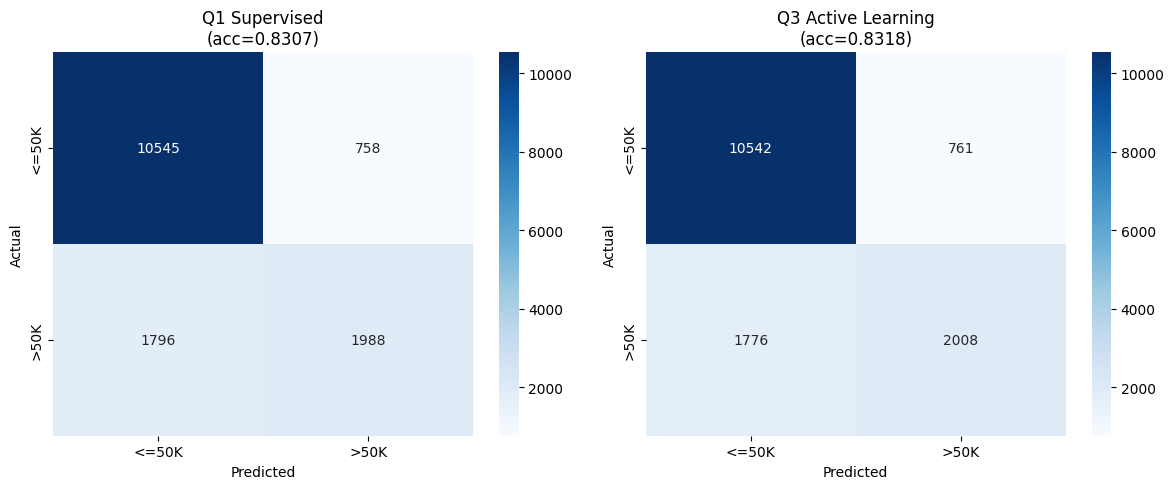

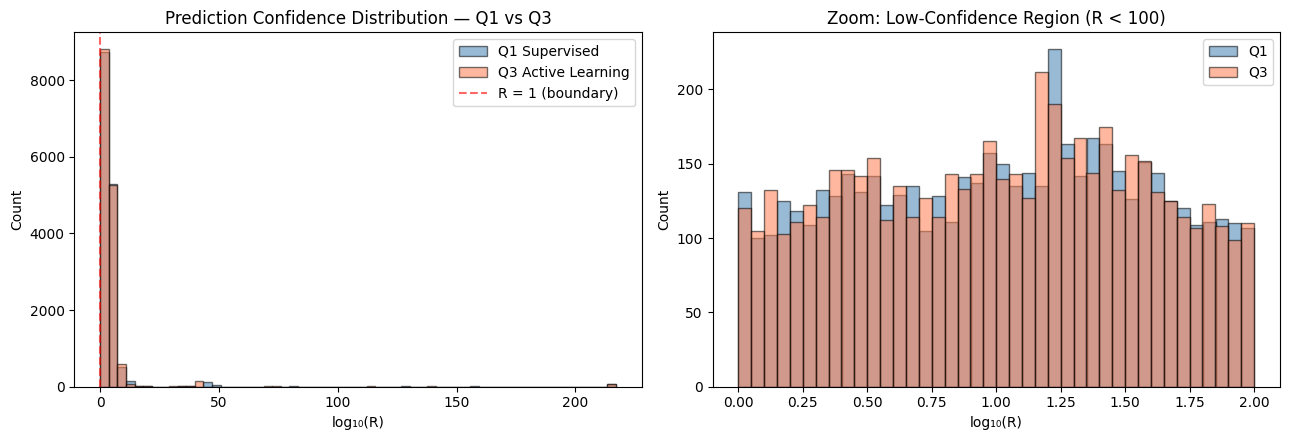

Q1 — Median R: 1.19e+03,  R < 2 (near boundary): 685
Q3 — Median R: 1.08e+03,  R < 2 (near boundary): 698

===== Continuous Feature Parameter Changes (Q1 → Q3) =====
       feature class mean_Q1 mean_Q3   Δmean   std_Q1   std_Q3    Δstd
           age <=50K   37.05   37.04  -0.012    13.71    13.71  -0.004
           age  >50K   43.94   43.91  -0.031    10.30    10.28  -0.020
 education-num <=50K    9.63    9.63  +0.003     2.45     2.45  -0.001
 education-num  >50K   11.59   11.60  +0.003     2.36     2.36  -0.004
  capital-gain <=50K  157.67  160.37  +2.702  1017.86  1083.45 +65.589
  capital-gain  >50K 3607.15 3623.57 +16.420 13616.62 13626.94 +10.314
  capital-loss <=50K   55.97   56.40  +0.421   316.02   317.30  +1.284
  capital-loss  >50K  202.36  201.68  -0.686   603.99   602.96  -1.027
hours-per-week <=50K   39.43   39.42  -0.004    11.91    11.89  -0.016
hours-per-week  >50K   45.64   45.64  -0.006    10.40    10.41  +0.011

===== Top Categorical Predictors: Q1 vs Q3 =====

Q1

In [63]:
# =============================================================================
# Q4 — Semi-Supervised Model Evaluation
# =============================================================================
# Compare the Q1 supervised model (mixed_nb_model) with the Q3 active-learning
# model (q3_final_model) on the held-out test set.
# =============================================================================

# ---- 1. Test-set predictions for both models ----

y_pred_q1, log_post_q1 = predict_mixed_nb(X_test_cont, X_test_cat, mixed_nb_model)
y_pred_q3, log_post_q3 = predict_mixed_nb(X_test_cont, X_test_cat, q3_final_model)

# ---- 2. Side-by-side metrics ----

def model_metrics(y_true, y_pred, label):
    acc  = accuracy_score(y_true, y_pred)
    p0   = precision_score(y_true, y_pred, pos_label=0)
    r0   = recall_score(y_true, y_pred, pos_label=0)
    f0   = f1_score(y_true, y_pred, pos_label=0)
    p1   = precision_score(y_true, y_pred, pos_label=1)
    r1   = recall_score(y_true, y_pred, pos_label=1)
    f1   = f1_score(y_true, y_pred, pos_label=1)
    mf1  = f1_score(y_true, y_pred, average='macro')
    return {'model': label, 'accuracy': acc,
            'prec_<=50K': p0, 'rec_<=50K': r0, 'F1_<=50K': f0,
            'prec_>50K': p1, 'rec_>50K': r1, 'F1_>50K': f1,
            'macro_F1': mf1}

metrics_q1 = model_metrics(y_test, y_pred_q1, 'Q1 Supervised')
metrics_q3 = model_metrics(y_test, y_pred_q3, 'Q3 Active Learning')

comparison_df = pd.DataFrame([metrics_q1, metrics_q3])
print("===== Test-Set Performance Comparison =====")
print(comparison_df.to_string(index=False))

print("\n--- Q1 Supervised ---")
print(classification_report(y_test, y_pred_q1, target_names=['<=50K', '>50K']))

print("--- Q3 Active Learning ---")
print(classification_report(y_test, y_pred_q3, target_names=['<=50K', '>50K']))

# ---- 3. Confusion matrices side by side ----

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in zip(axes,
                              [y_pred_q1, y_pred_q3],
                              ['Q1 Supervised', 'Q3 Active Learning']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title}\n(acc={accuracy_score(y_test, y_pred):.4f})')
plt.tight_layout()
plt.show()

# ---- 4. Confidence distribution shift ----

def compute_R(log_posterior):
    log_diff = np.abs(log_posterior[:, 1] - log_posterior[:, 0])
    return np.exp(np.minimum(log_diff, 500))

R_q1 = compute_R(log_post_q1)
R_q3 = compute_R(log_post_q3)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Full distribution
for R_vals, label, color in [(R_q1, 'Q1 Supervised', 'steelblue'),
                              (R_q3, 'Q3 Active Learning', 'coral')]:
    log10_R = np.log10(np.clip(R_vals, 1, None))
    axes[0].hist(log10_R, bins=60, alpha=0.55, color=color, edgecolor='black', label=label)
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.6, label='R = 1 (boundary)')
axes[0].set_xlabel('log₁₀(R)')
axes[0].set_ylabel('Count')
axes[0].set_title('Prediction Confidence Distribution — Q1 vs Q3')
axes[0].legend()

# Zoom: low-confidence region
for R_vals, label, color in [(R_q1, 'Q1', 'steelblue'),
                              (R_q3, 'Q3', 'coral')]:
    low = np.log10(np.clip(R_vals, 1, None))
    low = low[low < 2]
    axes[1].hist(low, bins=40, alpha=0.55, color=color, edgecolor='black', label=label)
axes[1].set_xlabel('log₁₀(R)')
axes[1].set_ylabel('Count')
axes[1].set_title('Zoom: Low-Confidence Region (R < 100)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Q1 — Median R: {np.median(R_q1):.2e},  R < 2 (near boundary): {(R_q1 < 2).sum()}")
print(f"Q3 — Median R: {np.median(R_q3):.2e},  R < 2 (near boundary): {(R_q3 < 2).sum()}")

# ---- 5. Feature parameter changes ----

gnb_q1 = mixed_nb_model['gnb']
gnb_q3 = q3_final_model['gnb']
cnb_q1 = mixed_nb_model['cnb']
cnb_q3 = q3_final_model['cnb']

# 5a. Continuous features — mean and std changes
print("\n===== Continuous Feature Parameter Changes (Q1 → Q3) =====")
param_rows = []
for j, feat in enumerate(CONTINUOUS_FEATURES):
    for c, c_label in CLASS_LABELS.items():
        mu_q1  = gnb_q1.theta_[c, j]
        mu_q3  = gnb_q3.theta_[c, j]
        std_q1 = np.sqrt(gnb_q1.var_[c, j])
        std_q3 = np.sqrt(gnb_q3.var_[c, j])
        param_rows.append({
            'feature': feat, 'class': c_label,
            'mean_Q1': f'{mu_q1:.2f}', 'mean_Q3': f'{mu_q3:.2f}', 'Δmean': f'{mu_q3-mu_q1:+.3f}',
            'std_Q1': f'{std_q1:.2f}', 'std_Q3': f'{std_q3:.2f}', 'Δstd': f'{std_q3-std_q1:+.3f}',
        })
param_change_df = pd.DataFrame(param_rows)
print(param_change_df.to_string(index=False))

# 5b. Top categorical predictors — compare R ratios for each class
print("\n===== Top Categorical Predictors: Q1 vs Q3 =====")

def top_categorical_ratios(model, top_n=5):
    """Return the top_n most predictive category values per class using P(v|c1)/P(v|c0)."""
    enc = model['encoder']
    cnb_model = model['cnb']
    rows = []
    for feat_idx, feat_name in enumerate(CATEGORICAL_FEATURES):
        log_probs = cnb_model.feature_log_prob_[feat_idx]
        categories = enc.categories_[feat_idx]
        for v_idx, v_name in enumerate(categories):
            if v_idx >= log_probs.shape[1]:
                continue
            log_ratio = log_probs[1, v_idx] - log_probs[0, v_idx]  # log P(v|>50K) / P(v|<=50K)
            rows.append({'feature': feat_name, 'value': v_name, 'log_ratio': log_ratio})
    ratio_df = pd.DataFrame(rows)

    top_high = ratio_df.nlargest(top_n, 'log_ratio').copy()
    top_high['R'] = np.exp(top_high['log_ratio'])
    top_high['favours'] = '>50K'

    top_low = ratio_df.nsmallest(top_n, 'log_ratio').copy()
    top_low['R'] = np.exp(-top_low['log_ratio'])
    top_low['favours'] = '<=50K'

    return pd.concat([top_high, top_low], ignore_index=True)

top_q1 = top_categorical_ratios(mixed_nb_model, top_n=5)
top_q3 = top_categorical_ratios(q3_final_model, top_n=5)

print("\nQ1 Supervised — Top predictors:")
print(top_q1[['feature', 'value', 'favours', 'R']].to_string(index=False))

print("\nQ3 Active Learning — Top predictors:")
print(top_q3[['feature', 'value', 'favours', 'R']].to_string(index=False))

# 5c. Prior probabilities comparison
print("\n===== Prior Probability Changes =====")
print(f"Q1 priors: P(<=50K) = {gnb_q1.class_prior_[0]:.4f}, P(>50K) = {gnb_q1.class_prior_[1]:.4f}")
print(f"Q3 priors: P(<=50K) = {gnb_q3.class_prior_[0]:.4f}, P(>50K) = {gnb_q3.class_prior_[1]:.4f}")